# Data Analysis and Visualization

This notebook analyzes summary outputs in `outputs/` and generates reusable figures for model comparison.

## Inputs
- `outputs/metrics_summary.tsv`
- `outputs/final_categorization.tsv`

## Outputs
- `outputs/analysis_summary.md`
- `outputs/figures/*.png`

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Resolve project root robustly whether notebook runs from repo root or scripts/
if (Path.cwd() / "outputs").exists():
    ROOT = Path.cwd()
elif (Path.cwd().parent / "outputs").exists():
    ROOT = Path.cwd().parent
else:
    ROOT = Path("..").resolve()

OUTPUTS = ROOT / "outputs"
FIG_DIR = OUTPUTS / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

metrics_path = OUTPUTS / "metrics_summary.tsv"
categorization_path = OUTPUTS / "final_categorization.tsv"

metrics_df = pd.read_csv(metrics_path, sep="\t")
cat_df = pd.read_csv(categorization_path, sep="\t")

print("project root:", ROOT)
print("metrics rows:", len(metrics_df))
print("categorization rows:", len(cat_df))
metrics_df.head()

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


metrics rows: 60
categorization rows: 7


,Dimension,Key,Model,RR,PCR,FCR,n,split
0,by_group,EN,chatgpt,100.00%,0.00%,0.00%,100,0
1,by_group,EN,deepseek,89.00%,0.00%,11.00%,100,0
2,by_group,EN,gemini,93.88%,2.04%,4.08%,98,1
3,by_group,EN-SW,chatgpt,100.00%,0.00%,0.00%,100,0
4,by_group,EN-SW,deepseek,84.00%,1.00%,15.00%,100,0


In [2]:
# Parse percentage metrics to numeric proportions
for col in ["RR", "PCR", "FCR"]:
    metrics_df[col] = metrics_df[col].str.rstrip("%").astype(float) / 100.0

# Quality checks
metrics_df["sum_check"] = metrics_df[["RR", "PCR", "FCR"]].sum(axis=1)
metrics_df["sum_error"] = (metrics_df["sum_check"] - 1.0).abs()
metrics_df["qa_flag"] = np.where(metrics_df["sum_error"] > 1e-3, "bad", "ok")

qa_summary = metrics_df["qa_flag"].value_counts(dropna=False)
print("QA flags:")
print(qa_summary)

metrics_df[["Dimension", "Key", "Model", "RR", "PCR", "FCR", "n", "split", "sum_check", "qa_flag"]].head()

QA flags:
qa_flag
ok    60
Name: count, dtype: int64


,Dimension,Key,Model,RR,PCR,FCR,n,split,sum_check,qa_flag
0,by_group,EN,chatgpt,1.0000,0.0000,0.0000,100,0,1.0,ok
1,by_group,EN,deepseek,0.8900,0.0000,0.1100,100,0,1.0,ok
2,by_group,EN,gemini,0.9388,0.0204,0.0408,98,1,1.0,ok
3,by_group,EN-SW,chatgpt,1.0000,0.0000,0.0000,100,0,1.0,ok
4,by_group,EN-SW,deepseek,0.8400,0.0100,0.1500,100,0,1.0,ok


In [3]:
# Weighted model summary across each dimension
summary = (
    metrics_df
    .groupby(["Dimension", "Model"], as_index=False)
    .apply(lambda g: pd.Series({
        "weighted_RR": np.average(g["RR"], weights=g["n"]),
        "weighted_PCR": np.average(g["PCR"], weights=g["n"]),
        "weighted_FCR": np.average(g["FCR"], weights=g["n"]),
        "fcr_std": g["FCR"].std(ddof=0),
        "rows": len(g),
        "total_n": g["n"].sum(),
        "total_split": g["split"].sum(),
    }))
    .reset_index(drop=True)
)

summary = summary.sort_values(["Dimension", "weighted_FCR", "weighted_RR"], ascending=[True, True, False])
summary.head(15)

/var/folders/17/x_pqdqgd6y3g9jtg7lchg8rh0000gn/T/ipykernel_6899/3884844063.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics_df


,Dimension,Model,weighted_RR,weighted_PCR,weighted_FCR,fcr_std,rows,total_n,total_split
0,by_category,chatgpt,1.000000,0.000000,0.000000,0.000000,5.0,900.0,0.0
1,by_category,deepseek,0.963258,0.002220,0.034522,0.024777,5.0,898.0,2.0
2,by_category,gemini,0.869546,0.034864,0.095610,0.111478,5.0,889.0,5.0
3,by_context_lang,chatgpt,1.000000,0.000000,0.000000,0.000000,3.0,900.0,0.0
4,by_context_lang,deepseek,0.963263,0.002238,0.034498,0.024449,3.0,898.0,2.0
5,by_context_lang,gemini,0.869507,0.034857,0.095636,0.032614,3.0,889.0,5.0
6,by_group,chatgpt,1.000000,0.000000,0.000000,0.000000,9.0,900.0,0.0
7,by_group,deepseek,0.963253,0.002227,0.034519,0.053366,9.0,898.0,2.0
8,by_group,gemini,0.869537,0.034864,0.095599,0.050029,9.0,889.0,5.0
9,by_keyword_lang,chatgpt,1.000000,0.000000,0.000000,0.000000,3.0,900.0,0.0


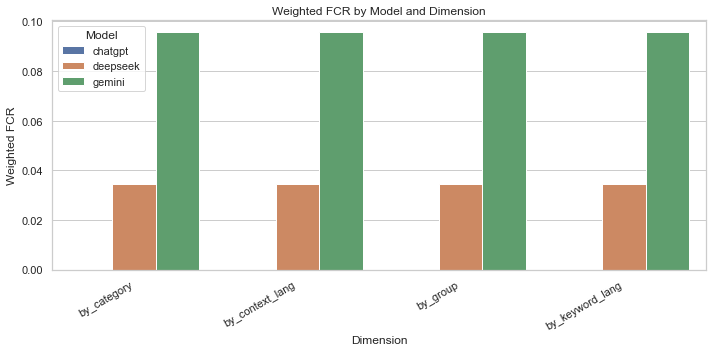

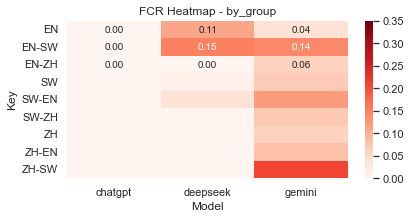

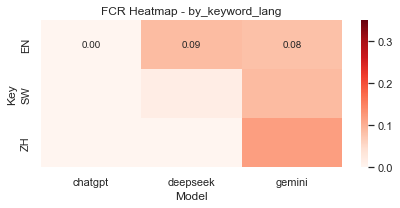

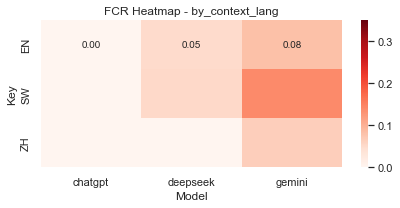

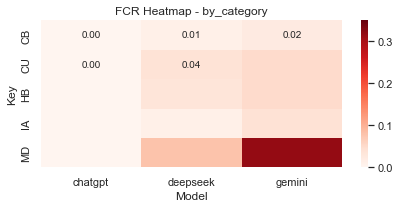

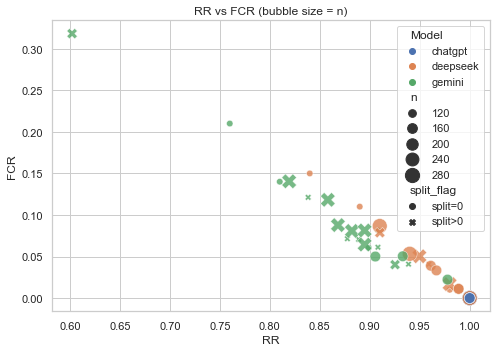

In [4]:
# Figure 1: weighted FCR by model and dimension
plt.figure(figsize=(10, 5))
sns.barplot(data=summary, x="Dimension", y="weighted_FCR", hue="Model")
plt.title("Weighted FCR by Model and Dimension")
plt.ylabel("Weighted FCR")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "overview_weighted_fcr.png", dpi=180)
plt.show()

# Figure 2: FCR heatmap by key x model (faceted by dimension)
for dim in metrics_df["Dimension"].unique():
    d = metrics_df[metrics_df["Dimension"] == dim]
    pivot = d.pivot(index="Key", columns="Model", values="FCR").sort_index()
    plt.figure(figsize=(6, max(3, 0.35 * len(pivot))))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=max(0.35, np.nanmax(pivot.values)))
    plt.title(f"FCR Heatmap - {dim}")
    plt.tight_layout()
    out = FIG_DIR / f"fcr_heatmap_{dim}.png"
    plt.savefig(out, dpi=180)
    plt.show()

# Figure 3: RR vs FCR bubble chart
plt.figure(figsize=(7, 5))
plot_df = metrics_df.copy()
plot_df["split_flag"] = np.where(plot_df["split"] > 0, "split>0", "split=0")
sns.scatterplot(
    data=plot_df,
    x="RR",
    y="FCR",
    size="n",
    hue="Model",
    style="split_flag",
    sizes=(40, 220),
    alpha=0.8,
)
plt.title("RR vs FCR (bubble size = n)")
plt.tight_layout()
plt.savefig(FIG_DIR / "rr_vs_fcr_bubble.png", dpi=180)
plt.show()

In [5]:
# Build concise markdown analysis summary
worst_cells = (
    metrics_df
    .sort_values(["FCR", "split"], ascending=[False, False])
    [["Dimension", "Key", "Model", "FCR", "RR", "PCR", "n", "split"]]
    .head(10)
)

best_cells = (
    metrics_df
    .sort_values(["FCR", "RR"], ascending=[True, False])
    [["Dimension", "Key", "Model", "FCR", "RR", "PCR", "n", "split"]]
    .head(10)
)

lines = []
lines.append("# Analysis Summary\n")
lines.append("## Top Risk Hotspots (highest FCR)\n")
for _, r in worst_cells.iterrows():
    lines.append(
        f"- {r['Model']} | {r['Dimension']}:{r['Key']} | FCR={r['FCR']:.2%}, RR={r['RR']:.2%}, n={int(r['n'])}, split={int(r['split'])}"
    )

lines.append("\n## Strongest Cells (lowest FCR)\n")
for _, r in best_cells.iterrows():
    lines.append(
        f"- {r['Model']} | {r['Dimension']}:{r['Key']} | FCR={r['FCR']:.2%}, RR={r['RR']:.2%}, n={int(r['n'])}, split={int(r['split'])}"
    )

summary_path = OUTPUTS / "analysis_summary.md"
summary_path.write_text("\n".join(lines), encoding="utf-8")

print(f"Wrote: {summary_path}")
print(f"Figures in: {FIG_DIR}")
worst_cells

Wrote: /Users/dradra-cl/Desktop/cs444/outputs/analysis_summary.md
Figures in: /Users/dradra-cl/Desktop/cs444/outputs/figures


,Dimension,Key,Model,FCR,RR,PCR,n,split
59,by_category,MD,gemini,0.3182,0.6023,0.0795,176,4
26,by_group,ZH-SW,gemini,0.2100,0.7600,0.0300,100,0
4,by_group,EN-SW,deepseek,0.1500,0.8400,0.0100,100,0
41,by_context_lang,SW,gemini,0.1405,0.8194,0.0401,299,1
5,by_group,EN-SW,gemini,0.1400,0.8100,0.0500,100,0
14,by_group,SW-EN,gemini,0.1212,0.8384,0.0404,99,1
35,by_keyword_lang,ZH,gemini,0.1182,0.8581,0.0236,296,1
1,by_group,EN,deepseek,0.1100,0.8900,0.0000,100,0
32,by_keyword_lang,SW,gemini,0.0878,0.8682,0.0439,296,3
28,by_keyword_lang,EN,deepseek,0.0867,0.9100,0.0033,300,0


## Detailed diagnostics

This section adds deeper statistical diagnostics and additional visualizations:

- Confidence intervals for FCR by model and dimension
- Split-aware reliability checks
- Gap-to-best analysis by key
- Pairwise model tests on aggregated FCR

In [ ]:
# Prepare detailed analysis tables
from math import sqrt

metrics_df = metrics_df.copy()
metrics_df["total_with_split"] = metrics_df["n"] + metrics_df["split"]
metrics_df["split_rate"] = np.where(metrics_df["total_with_split"] > 0,
                                    metrics_df["split"] / metrics_df["total_with_split"],
                                    0.0)

# Reliability-adjusted effective sample size (penalize split-heavy cells)
metrics_df["effective_n"] = metrics_df["n"] * (1 - metrics_df["split_rate"])
metrics_df["effective_n"] = metrics_df["effective_n"].clip(lower=1)

# Wilson interval helper for proportions

def wilson_interval(p: float, n: int, z: float = 1.96):
    if n <= 0 or pd.isna(p):
        return np.nan, np.nan
    denom = 1 + (z ** 2) / n
    center = (p + (z ** 2) / (2 * n)) / denom
    margin = (z / denom) * sqrt((p * (1 - p) / n) + ((z ** 2) / (4 * n ** 2)))
    lo, hi = max(0.0, center - margin), min(1.0, center + margin)
    return lo, hi

metrics_df[["fcr_ci_lo", "fcr_ci_hi"]] = metrics_df.apply(
    lambda r: pd.Series(wilson_interval(r["FCR"], int(r["n"]))), axis=1
)

# Long format for flexible plotting
long_df = metrics_df.melt(
    id_vars=["Dimension", "Key", "Model", "n", "split", "split_rate", "effective_n", "fcr_ci_lo", "fcr_ci_hi"],
    value_vars=["RR", "PCR", "FCR"],
    var_name="Metric",
    value_name="Value",
)

# Dimension-level model summary with split-aware weighting
weighted_detailed = (
    metrics_df
    .groupby(["Dimension", "Model"], as_index=False)
    .apply(lambda g: pd.Series({
        "weighted_RR": np.average(g["RR"], weights=g["effective_n"]),
        "weighted_PCR": np.average(g["PCR"], weights=g["effective_n"]),
        "weighted_FCR": np.average(g["FCR"], weights=g["effective_n"]),
        "mean_split_rate": g["split_rate"].mean(),
        "total_n": g["n"].sum(),
        "total_split": g["split"].sum(),
    }))
    .reset_index(drop=True)
)

weighted_detailed = weighted_detailed.sort_values(["Dimension", "weighted_FCR", "mean_split_rate"])
weighted_detailed.head(20)

In [ ]:
# Figure 4: FCR with 95% CI by dimension/model
plot_fcr = metrics_df.sort_values(["Dimension", "Key", "Model"]).copy()

n_dims = plot_fcr["Dimension"].nunique()
fig, axes = plt.subplots(n_dims, 1, figsize=(10, 3.0 * n_dims), sharex=False)
if n_dims == 1:
    axes = [axes]

for ax, dim in zip(axes, sorted(plot_fcr["Dimension"].unique())):
    d = plot_fcr[plot_fcr["Dimension"] == dim].copy()
    d["label"] = d["Key"] + " | " + d["Model"]
    d = d.sort_values(["FCR", "split_rate"], ascending=[False, False])

    x = np.arange(len(d))
    y = d["FCR"].to_numpy()
    yerr_low = y - d["fcr_ci_lo"].to_numpy()
    yerr_high = d["fcr_ci_hi"].to_numpy() - y

    ax.errorbar(x, y, yerr=[yerr_low, yerr_high], fmt="o", capsize=3)
    ax.set_title(f"FCR with 95% CI - {dim}")
    ax.set_ylabel("FCR")
    ax.set_xticks(x)
    ax.set_xticklabels(d["label"], rotation=75, ha="right", fontsize=8)
    ax.set_ylim(0, min(1.0, max(0.2, d["fcr_ci_hi"].max() + 0.05)))

plt.tight_layout()
plt.savefig(FIG_DIR / "fcr_with_ci_by_dimension.png", dpi=180)
plt.show()

# Figure 5: Split-rate heatmap (reliability diagnostic)
for dim in metrics_df["Dimension"].unique():
    d = metrics_df[metrics_df["Dimension"] == dim]
    pivot = d.pivot(index="Key", columns="Model", values="split_rate").sort_index()
    plt.figure(figsize=(6, max(3, 0.35 * len(pivot))))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=max(0.15, np.nanmax(pivot.values)))
    plt.title(f"Split Rate Heatmap - {dim}")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"split_heatmap_{dim}.png", dpi=180)
    plt.show()

In [ ]:
# Figure 6: Gap-to-best FCR by key (lower is better)
gap_rows = []
for dim in metrics_df["Dimension"].unique():
    d = metrics_df[metrics_df["Dimension"] == dim]
    for key in d["Key"].unique():
        dk = d[d["Key"] == key].copy()
        best_fcr = dk["FCR"].min()
        for _, r in dk.iterrows():
            gap_rows.append({
                "Dimension": dim,
                "Key": key,
                "Model": r["Model"],
                "FCR": r["FCR"],
                "gap_to_best_fcr": r["FCR"] - best_fcr,
                "n": r["n"],
                "split_rate": r["split_rate"],
            })

gap_df = pd.DataFrame(gap_rows)
for dim in gap_df["Dimension"].unique():
    d = gap_df[gap_df["Dimension"] == dim]
    pivot = d.pivot(index="Key", columns="Model", values="gap_to_best_fcr").sort_index()
    plt.figure(figsize=(6, max(3, 0.35 * len(pivot))))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="OrRd", vmin=0)
    plt.title(f"FCR Gap to Best Model - {dim}")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"fcr_gap_to_best_{dim}.png", dpi=180)
    plt.show()

# Figure 7: Reliability-adjusted model ranking
overall_rank = (
    metrics_df
    .groupby("Model", as_index=False)
    .apply(lambda g: pd.Series({
        "adj_weighted_FCR": np.average(g["FCR"], weights=g["effective_n"]),
        "adj_weighted_RR": np.average(g["RR"], weights=g["effective_n"]),
        "mean_split_rate": g["split_rate"].mean(),
        "total_effective_n": g["effective_n"].sum(),
    }))
    .reset_index(drop=True)
    .sort_values(["adj_weighted_FCR", "adj_weighted_RR"], ascending=[True, False])
)

plt.figure(figsize=(7, 4))
sns.barplot(data=overall_rank, x="Model", y="adj_weighted_FCR")
plt.title("Reliability-Adjusted Overall FCR by Model")
plt.ylabel("Adjusted Weighted FCR")
plt.tight_layout()
plt.savefig(FIG_DIR / "adjusted_overall_fcr_by_model.png", dpi=180)
plt.show()

overall_rank

In [ ]:
# Pairwise z-tests on aggregate FCR (approximate, pooled proportions)
def z_test_two_props(fails_a, n_a, fails_b, n_b):
    if n_a <= 0 or n_b <= 0:
        return np.nan
    p_a = fails_a / n_a
    p_b = fails_b / n_b
    p_pool = (fails_a + fails_b) / (n_a + n_b)
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / n_a + 1 / n_b))
    if se == 0:
        return 0.0
    return (p_a - p_b) / se

model_agg = (
    metrics_df
    .groupby("Model", as_index=False)
    .apply(lambda g: pd.Series({
        "fails": float((g["FCR"] * g["n"]).sum()),
        "n": float(g["n"].sum()),
    }))
    .reset_index(drop=True)
)

pairs = []
for i in range(len(model_agg)):
    for j in range(i + 1, len(model_agg)):
        a = model_agg.iloc[i]
        b = model_agg.iloc[j]
        z = z_test_two_props(a["fails"], a["n"], b["fails"], b["n"])
        pairs.append({
            "model_a": a["Model"],
            "model_b": b["Model"],
            "z_stat": z,
            "abs_z": abs(z),
        })

pairwise_df = pd.DataFrame(pairs).sort_values("abs_z", ascending=False)

# Write enhanced summary markdown
worst_detailed = metrics_df.sort_values(["FCR", "split_rate"], ascending=[False, False]).head(15)
best_detailed = metrics_df.sort_values(["FCR", "split_rate", "RR"], ascending=[True, True, False]).head(15)

summary_lines = []
summary_lines.append("# Detailed Analysis Summary\n")
summary_lines.append("## Overall Reliability-Adjusted Ranking (lower FCR is better)\n")
for _, r in overall_rank.iterrows():
    summary_lines.append(
        f"- {r['Model']}: adjusted_FCR={r['adj_weighted_FCR']:.2%}, adjusted_RR={r['adj_weighted_RR']:.2%}, mean_split_rate={r['mean_split_rate']:.2%}"
    )

summary_lines.append("\n## Largest Pairwise FCR Differences (z-stat)\n")
for _, r in pairwise_df.head(5).iterrows():
    summary_lines.append(
        f"- {r['model_a']} vs {r['model_b']}: z={r['z_stat']:.2f}"
    )

summary_lines.append("\n## Top 15 Risk Hotspots\n")
for _, r in worst_detailed.iterrows():
    summary_lines.append(
        f"- {r['Model']} | {r['Dimension']}:{r['Key']} | FCR={r['FCR']:.2%}, RR={r['RR']:.2%}, split_rate={r['split_rate']:.2%}, n={int(r['n'])}"
    )

summary_lines.append("\n## Top 15 Strong Cells\n")
for _, r in best_detailed.iterrows():
    summary_lines.append(
        f"- {r['Model']} | {r['Dimension']}:{r['Key']} | FCR={r['FCR']:.2%}, RR={r['RR']:.2%}, split_rate={r['split_rate']:.2%}, n={int(r['n'])}"
    )

summary_lines.append("\n## Notes\n")
summary_lines.append("- Split labels are excluded from RR/PCR/FCR denominators by design.")
summary_lines.append("- Weighted metrics use split-adjusted effective sample sizes to reduce ambiguity-driven bias.")
summary_lines.append("- Pairwise z-tests are approximate and intended for directional comparison.")

detailed_summary_path = OUTPUTS / "analysis_summary_detailed.md"
detailed_summary_path.write_text("\n".join(summary_lines), encoding="utf-8")

# Persist data products
overall_rank.to_csv(OUTPUTS / "overall_rank_adjusted.csv", index=False)
weighted_detailed.to_csv(OUTPUTS / "weighted_detailed_by_dimension.csv", index=False)
pairwise_df.to_csv(OUTPUTS / "pairwise_fcr_ztests.csv", index=False)

detailed_summary_path, pairwise_df.head()